In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\DELL\Downloads\marketing_AB.csv\marketing_AB.csv")

In [3]:
df.head(3)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18


In [4]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [5]:
df.shape

(588101, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [7]:
df.duplicated().any()

np.False_

In [8]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [9]:
df["most ads day"].value_counts()

most ads day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

In [10]:
df.head(1)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20


##  A/B TEST

### BUSINESS PROBLEM

- company wants to know that which test group convert customers more

### A/B Test Design

- Group A - ad  # Users who saw the advertisement

- Group B - psa  # Users who saw a Public Service Announcement 


- Null Hypothesis(Ho) - test group and convertion are independet
- Alternate Hypothesis(H1) -  test group and convertion have related

In [11]:
from scipy.stats import chi2_contingency

In [12]:
table=pd.crosstab(df["test group"],df["converted"])
chi2,p_value,dof,expected=chi2_contingency(table)
print("chi_squar :" , chi2)
print("p_value :" , p_value)

chi_squar : 54.005823883685245
p_value : 1.9989623063390075e-13


In [13]:
if p_value< 0.05:
    print(" reject Null Hypothesis(Ho): test group and convertion have related")
else:
     print(" fail to reject Null Hypothesis(Ho): test group and convertion are independent")


 reject Null Hypothesis(Ho): test group and convertion have related


In [14]:
df2=df[["test group","converted"]]

In [15]:
df2.head

<bound method NDFrame.head of        test group  converted
0              ad      False
1              ad      False
2              ad      False
3              ad      False
4              ad      False
...           ...        ...
588096         ad      False
588097         ad      False
588098         ad      False
588099         ad      False
588100         ad      False

[588101 rows x 2 columns]>

In [16]:
df2.value_counts()

test group  converted
ad          False        550154
psa         False         23104
ad          True          14423
psa         True            420
Name: count, dtype: int64

In [17]:
d_count = df2[df2["test group"] == "ad"].shape[0]

d1_count = df2[(df2["test group"] == "ad") & (df2["converted"] == True)].shape[0]

per = round((d1_count / d_count) * 100, 2)

print("Conversion rate of ad:", per, "%")

Conversion rate of ad: 2.55 %


In [18]:
o_count = df2[df2["test group"] == "psa"].shape[0]

o1_count = df2[(df2["test group"] == "psa") & (df2["converted"] == True)].shape[0]

per = round((o1_count / o_count) * 100, 2)

print("Conversion rate of psa:", per, "%")

Conversion rate of psa: 1.79 %


##  BUSINESS INSIGHTS
When company go for  advertise then customers who saw advertisement tehn their convertion are 2.55 % and when comapany work on Public Service Announcement , who heard it, their convertion are 1.79 %

##  BUSINESS RECOMMENDATION
The advertisement group shows a higher conversion rate (2.55%) compared to the PSA group (1.79%). Since the chi-square test confirms a statistically significant relationship between test group and conversion (p < 0.05), the company should prioritize advertising campaigns to maximize customer conversions.

In [19]:
import seaborn as sns

<Axes: xlabel='test group', ylabel='converted'>

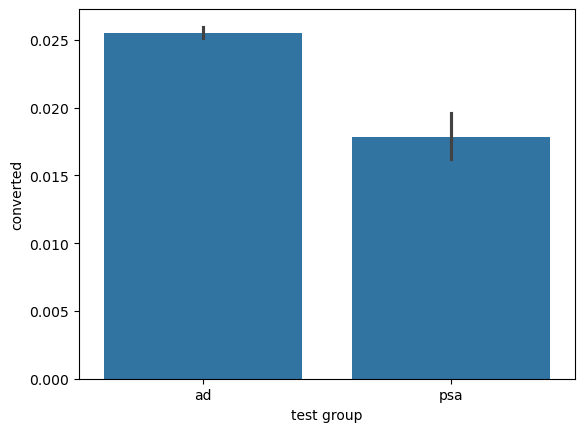

In [20]:
sns.barplot(x="test group", y="converted", data=df)

In [21]:
df.head(1)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20


## A/B TEST

# BUSINESS PROBLEM
- Company want to know that do ads hour effect convertion 

# A/B TEST DESIGN
- Group A -convertion is true
- Group B - convertion is false

# HYPOTHESIS

- Null Hypothesis(Ho)- ads hours does not effect convertion
- Alternate Hypothesis(H1)- ads hours effect convertion


In [22]:
from scipy.stats import ttest_ind

In [23]:
convertion_true=df[df["converted"]==True]["most ads hour"]
convertion_false=df[df["converted"]==False]["most ads hour"]

In [24]:
t_stat,p_value=ttest_ind(convertion_true,convertion_false)
print("p_value:",p_value)

p_value: 1.9213511553188872e-51


In [25]:
if p_value< 0.05:
    print(" reject Null Hypothesis(Ho): ads hours effect convertion ")
else:
     print(" fail to reject Null Hypothesis(Ho): ads hours does not effect convertion")

 reject Null Hypothesis(Ho): ads hours effect convertion 


In [26]:
df.groupby("converted")["most ads hour"].mean()

converted
False    14.453756
True     15.060163
Name: most ads hour, dtype: float64

## BUSINESS INSIGHTS
- The average ad viewing hour for converted users (15.06) is slightly higher than non-converted users (14.45). This suggests that ads viewed later in the day may have a slightly higher likelihood of conversion.

## BUSINESS RECOMMENDATION
- Schedule ads later in the afternoon and evening when conversions are slightly higher.
- Conduct further analysis to identify specific peak conversion hours.
- Optimize ad scheduling algorithms to prioritize high-conversion time windows.                                                                                          -

In [27]:
df.groupby("most ads hour")["converted"].mean()*100

most ads hour
0     1.842486
1     1.291129
2     0.731296
3     1.045166
4     1.523546
5     2.091503
6     2.224371
7     1.811085
8     1.951552
9     1.919107
10    2.152084
11    2.211643
12    2.382765
13    2.467737
14    2.806257
15    2.965334
16    3.077169
17    2.820967
18    2.737988
19    2.671982
20    2.980327
21    2.892314
22    2.610472
23    2.266191
Name: converted, dtype: float64

### Insight

- Conversion rates increase significantly during the afternoon and evening hours. The highest conversion rate (3.07%) occurs around 4 PM, while late-night hours such as 2 AM show very low conversion rates (0.73%).

### Recommendation

- Schedule advertisements during high-conversion hours (2 PM – 9 PM).
- Reduce ad spending during late-night hours (12 AM – 4 AM).
- Focus marketing campaigns on peak engagement times like 4 PM.

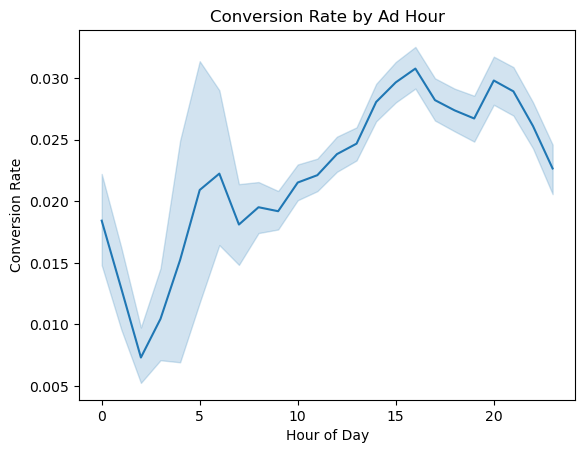

In [28]:

import matplotlib.pyplot as plt

sns.lineplot(x="most ads hour", y="converted", data=df)
plt.title("Conversion Rate by Ad Hour")
plt.ylabel("Conversion Rate")
plt.xlabel("Hour of Day")
plt.show()

In [29]:
df["ad_frequency_group"] = pd.cut(
    df["total ads"],
    bins=[0,5,20,50,100,200],
    labels=["Very Low","Low","Medium","High","Very High"]
)

In [30]:
df.groupby("ad_frequency_group")["converted"].mean()*100

C:\Users\DELL\AppData\Local\Temp\ipykernel_13160\2404628211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ad_frequency_group")["converted"].mean()*100


ad_frequency_group
Very Low      0.252498
Low           0.702827
Medium        2.885851
High         11.395157
Very High    17.367929
Name: converted, dtype: float64

### Insight

- Conversion rates increase significantly with higher ad exposure. Users exposed to a very high number of advertisements show the highest conversion rate (17.36%), while users exposed to very few ads have extremely low conversion rates (0.25%).

### Recommendation

- Increase ad exposure to users to improve conversion rates.
- Focus on maintaining consistent ad visibility across campaigns.
- Avoid extremely low ad exposure levels because they produce very low conversion rates.

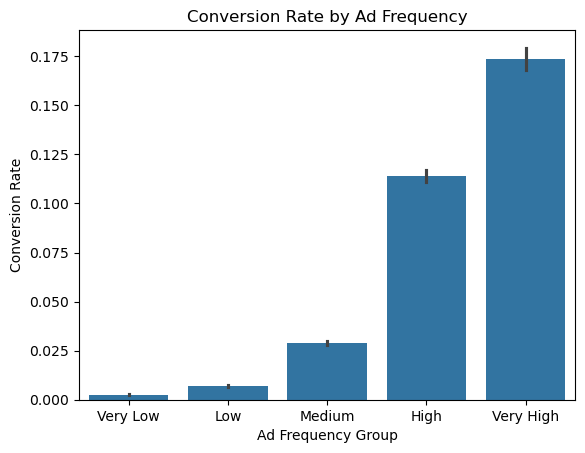

In [31]:
sns.barplot(x="ad_frequency_group", y="converted", data=df)
plt.title("Conversion Rate by Ad Frequency")
plt.ylabel("Conversion Rate")
plt.xlabel("Ad Frequency Group")
plt.show()